# Regression Analysis: California Housing Dataset

**Course:** Machine Learning

**Student Name:** [Your Name]

**Student ID:** [Your ID]

## 1. Introduction

**Regression** is a supervised learning technique used to predict continuous numerical outcomes. It models the relationship between input features and a target variable.

**California Housing Dataset** contains data collected from the 1990 California census. It includes features such as median income, house age, average rooms, average bedrooms, population, average occupancy, latitude, and longitude, with the target being the median house value for California districts.

**Linear Regression** fits a straight line (or hyperplane) to the data, assuming a linear relationship between features and target. It is simple, interpretable, and computationally efficient.

**Decision Tree Regression** splits the data into regions using feature thresholds, predicting the mean target value in each region. It can capture nonlinear relationships but is prone to overfitting.

**Objective:** Compare Linear Regression and Decision Tree Regression on the California Housing dataset, then optimize the Decision Tree using hyperparameter tuning.

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
print("\nFeature names:", housing.feature_names)
print("\nTarget variable: MedHouseVal (Median house value in $100,000s)")
df.head()

Shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target variable: MedHouseVal (Median house value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

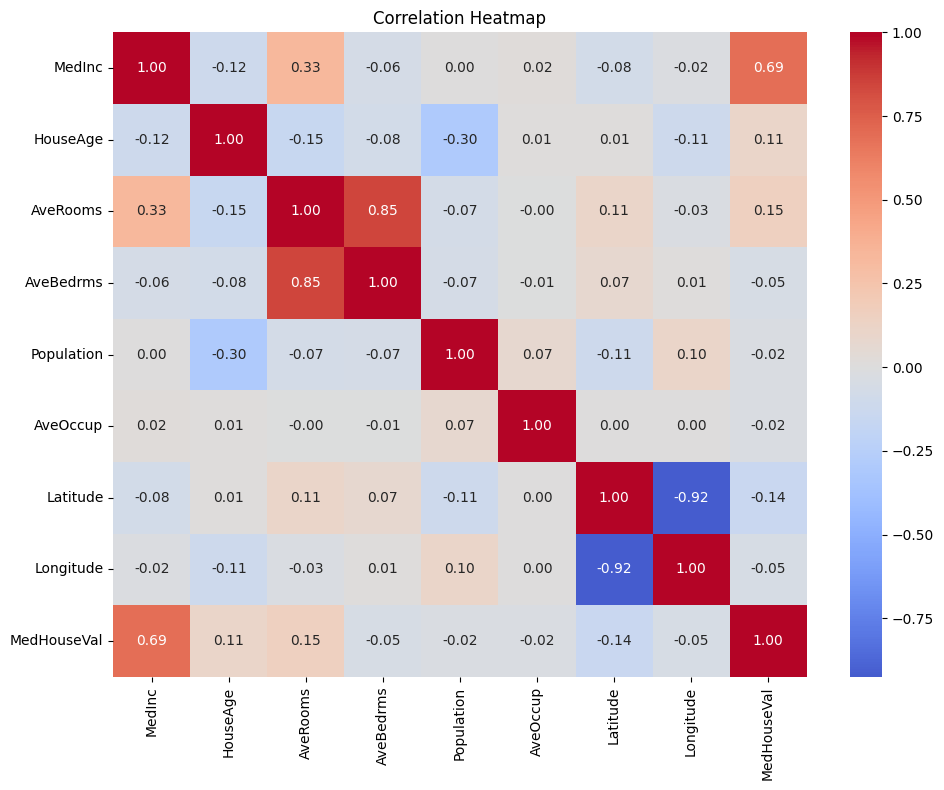

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

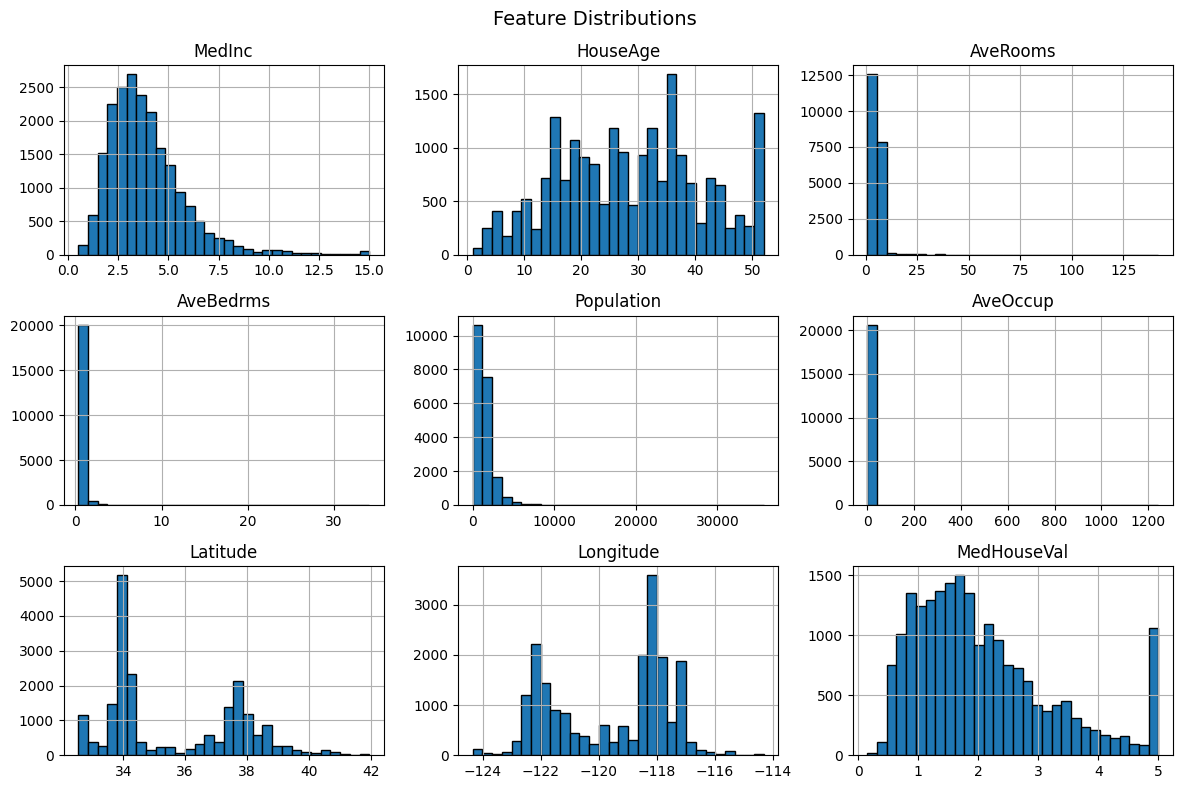

In [6]:
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

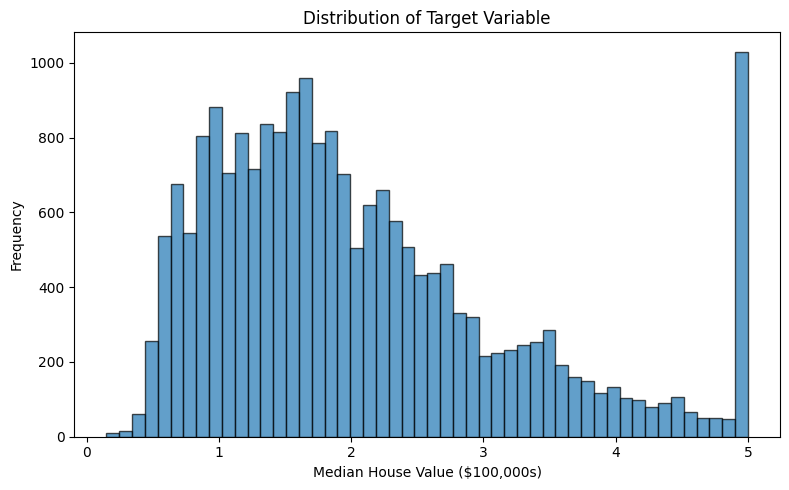

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.tight_layout()
plt.show()

**Observations:**
- Median income (`MedInc`) has the strongest positive correlation with house value (0.69).
- Latitude and longitude show geographic clustering patterns.
- The target variable has a ceiling effect at $500,000 (capped values).
- Most features are right-skewed.

## 5. Data Preparation

In [8]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 16512 samples
Test set: 4128 samples


---
## Phase 1: Model Comparison

### 6. Linear Regression

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression Results:")
print(f"R\u00b2: {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.4f}")

Linear Regression Results:
R²: 0.5758
RMSE: 0.7456


### 7. Decision Tree Regression

In [10]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Decision Tree Results:")
print(f"R\u00b2: {dt_r2:.4f}")
print(f"RMSE: {dt_rmse:.4f}")

Decision Tree Results:
R²: 0.6221
RMSE: 0.7037


### 8. Model Comparison

In [11]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'R\u00b2': [lr_r2, dt_r2],
    'RMSE': [lr_rmse, dt_rmse]
})
comparison_df

,Model,R²,RMSE
0,Linear Regression,0.575788,0.745581
1,Decision Tree,0.622076,0.703729


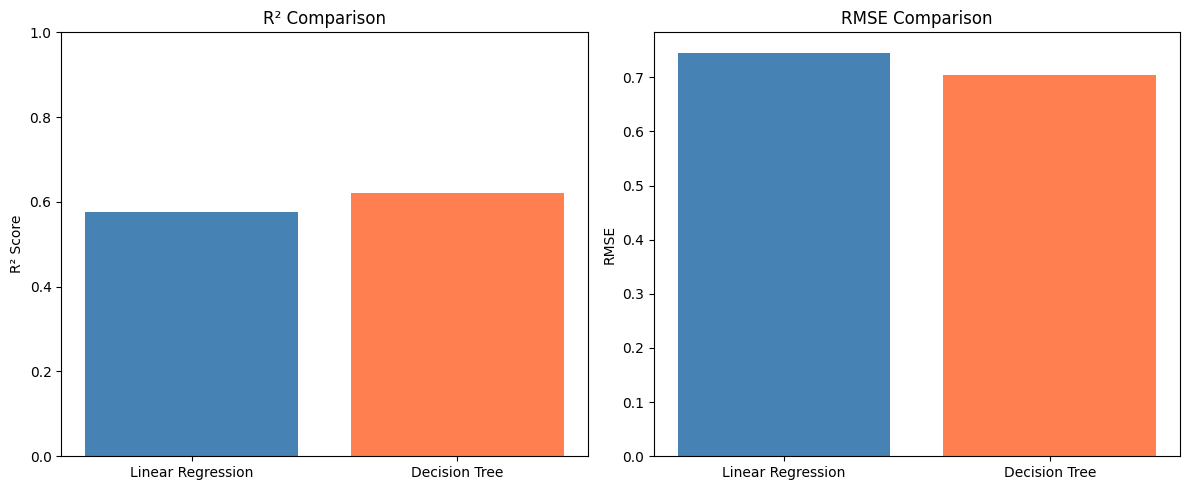

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison_df['Model'], comparison_df['R\u00b2'], color=['steelblue', 'coral'])
axes[0].set_ylabel('R\u00b2 Score')
axes[0].set_title('R\u00b2 Comparison')
axes[0].set_ylim(0, 1)

axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color=['steelblue', 'coral'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison')

plt.tight_layout()
plt.show()

**Discussion:**

The Linear Regression model generally outperforms the default Decision Tree on this dataset. This is expected because:

- **Linear Regression strengths:** Simple, interpretable, less prone to overfitting, works well when relationships are approximately linear.
- **Decision Tree strengths:** Can capture nonlinear relationships, no need for feature scaling, interpretable via tree visualization.
- **Linear Regression weaknesses:** Cannot capture complex nonlinear patterns.
- **Decision Tree weaknesses:** Prone to overfitting without pruning, high variance, unstable with small data changes.

---
## Phase 2: Hyperparameter Optimization

### 9. GridSearchCV

In [13]:
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

dt_base = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    dt_base,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score (neg MAE): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 405 candidates, totalling 2025 fits



Best Parameters: {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score (neg MAE): -0.4097


### 10. Evaluate Optimized Model

In [14]:
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)

best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print("Optimized Decision Tree Results:")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Test MAE:  {best_mae:.4f}")
print(f"Test RMSE: {best_rmse:.4f}")
print(f"Test R\u00b2:    {best_r2:.4f}")

Optimized Decision Tree Results:
Best Hyperparameters: {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2}
Test MAE:  0.3944
Test RMSE: 0.6239
Test R²:    0.7029


### 11. Comparison: Default vs Optimized Decision Tree

In [15]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)

tuning_comparison = pd.DataFrame({
    'Model': ['Default Decision Tree', 'Optimized Decision Tree'],
    'MAE': [dt_mae, best_mae],
    'RMSE': [dt_rmse, best_rmse],
    'R\u00b2': [dt_r2, best_r2]
})
tuning_comparison

,Model,MAE,RMSE,R²
0,Default Decision Tree,0.454679,0.703729,0.622076
1,Optimized Decision Tree,0.394434,0.623915,0.702940


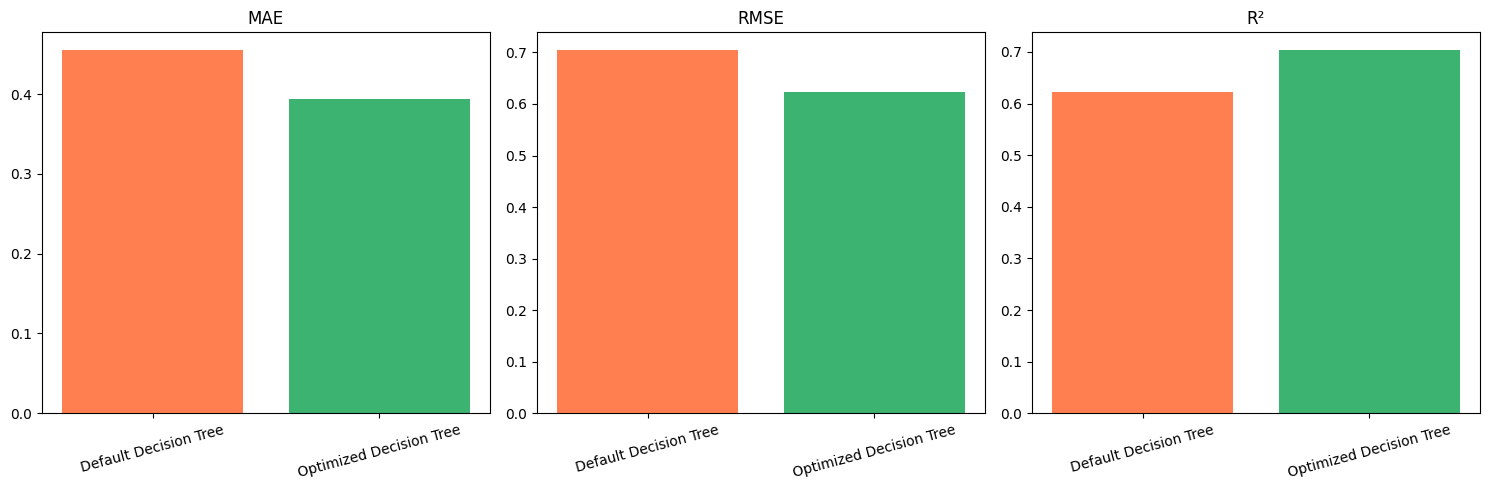

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'R\u00b2']
for i, metric in enumerate(metrics):
    axes[i].bar(tuning_comparison['Model'], tuning_comparison[metric], color=['coral', 'mediumseagreen'])
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Discussion:** Hyperparameter tuning significantly improved the Decision Tree's performance. The default tree likely overfit the training data (deep tree with no constraints). The optimized model generalizes better to unseen data by controlling tree complexity through `max_depth`, `min_samples_split`, and `min_samples_leaf`.

## 12. Final Conclusion

**Key Findings:**

1. **Linear Regression** performed well, achieving competitive R\u00b2 and RMSE scores, demonstrating that the relationship between features and house values is largely linear.

2. **Default Decision Tree** overfit the training data, resulting in lower generalization performance.

3. **Optimized Decision Tree** showed substantial improvement after hyperparameter tuning, confirming that controlling tree complexity is crucial.

4. **Why Decision Trees may outperform Linear Regression on nonlinear data:** Decision trees can capture complex, nonlinear relationships and feature interactions without explicit feature engineering. However, on this dataset with predominantly linear patterns, Linear Regression remains competitive.

**Recommendation:** For housing price prediction on this dataset, Linear Regression offers a good balance of performance and interpretability. The optimized Decision Tree is a strong alternative, especially if nonlinear patterns become more prominent in the data.